In [2]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

## Model Performance Metrics Diagnostics

In [23]:
# Load the CSV files
glr_df = pd.read_csv("../database/predicted_data/glr_predicted.csv")
gwr_df = pd.read_csv("../database/predicted_data/gwr_predicted.csv")
fbcr_df = pd.read_csv("../database/predicted_data/fbcr_predicted.csv")

In [27]:
# Calculate the performance metrics for each model
glr_mae = mean_absolute_error(glr_df["price"], glr_df["PREDICTED"])
glr_rmse = mean_squared_error(glr_df["price"], glr_df["PREDICTED"], squared=False)
glr_r2 = r2_score(glr_df["price"], glr_df["PREDICTED"])

gwr_mae = mean_absolute_error(gwr_df["price"], gwr_df["PREDICTED"])
gwr_rmse = mean_squared_error(gwr_df["price"], gwr_df["PREDICTED"], squared=False)
gwr_r2 = r2_score(gwr_df["price"], gwr_df["PREDICTED"])

fbcr_mae = mean_absolute_error(fbcr_df["PRICE"], fbcr_df["PREDICTED"])
fbcr_rmse = mean_squared_error(fbcr_df["PRICE"], fbcr_df["PREDICTED"], squared=False)
fbcr_r2 = r2_score(fbcr_df["PRICE"], fbcr_df["PREDICTED"])

# Print the results
print("GLR: MAE={}, RMSE={}, R2={}".format(glr_mae, glr_rmse, glr_r2))
print("GWR: MAE={}, RMSE={}, R2={}".format(gwr_mae, gwr_rmse, gwr_r2))
print("FBCR: MAE={}, RMSE={}, R2={}".format(fbcr_mae, fbcr_rmse, fbcr_r2))

GLR: MAE=30423.962843358757, RMSE=46278.412493550306, R2=0.6666615088218144
GWR: MAE=27032.122071295522, RMSE=41258.582087686635, R2=0.7400540486294145
FBCR: MAE=14053.22613003116, RMSE=22733.53833832878, R2=0.9192043740691891


## Scatterplots actual price vs predicted

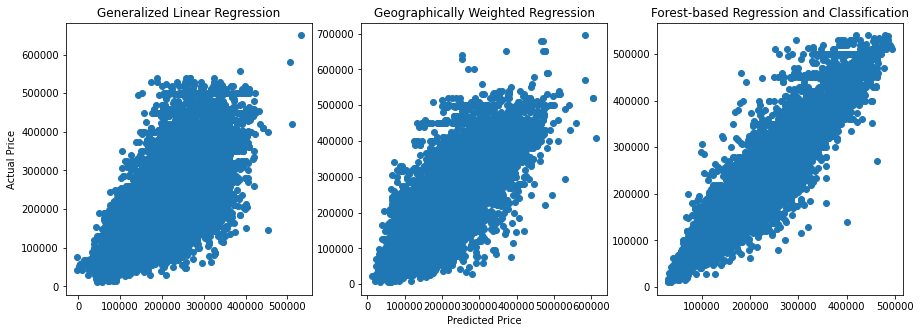

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Generalized Linear Regression model
axs[0].scatter(glr_df["PREDICTED"], glr_df["price"])
axs[0].set_title("Generalized Linear Regression")
axs[0].set_ylabel("Actual Price")

# Geographically Weighted Regression model
axs[1].scatter(gwr_df["PREDICTED"], gwr_df["price"])
axs[1].set_title("Geographically Weighted Regression")
axs[1].set_xlabel("Predicted Price")

# Forest-based Regression and Classification model
axs[2].scatter(fbcr_df["PREDICTED"], fbcr_df["PRICE"])
axs[2].set_title("Forest-based Regression and Classification")

plt.show()

## Distribution measurement

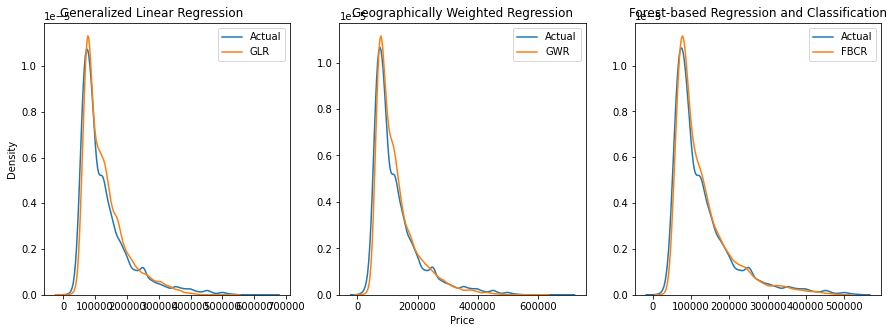

In [29]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Generalized Linear Regression model
sns.kdeplot(data=glr_df, x="price", label="Actual", ax=axs[0], legend=True)
sns.kdeplot(data=glr_df, x="PREDICTED", label="GLR", ax=axs[0], legend=True)
axs[0].set_title("Generalized Linear Regression        ")
axs[0].set_xlabel('')
axs[0].legend()

# Geographically Weighted Regression model
sns.kdeplot(data=gwr_df, x="price", label="Actual", ax=axs[1], legend=True)
sns.kdeplot(data=gwr_df, x="PREDICTED", label="GWR", ax=axs[1], legend=True)
axs[1].set_title("Geographically Weighted Regression")
axs[1].set_xlabel("Price")
axs[1].set_ylabel('')
axs[1].legend()

# Forest-based Regression and Classification model
sns.kdeplot(data=fbcr_df, x="PRICE", label="Actual", ax=axs[2], legend=True)
sns.kdeplot(data=fbcr_df, x="PREDICTED", label="FBCR", ax=axs[2], legend=True)
axs[2].set_title("Forest-based Regression and Classification")
axs[2].set_xlabel("")
axs[2].set_ylabel('')
axs[2].legend()

# Display the plots
plt.show()

### Model comparison

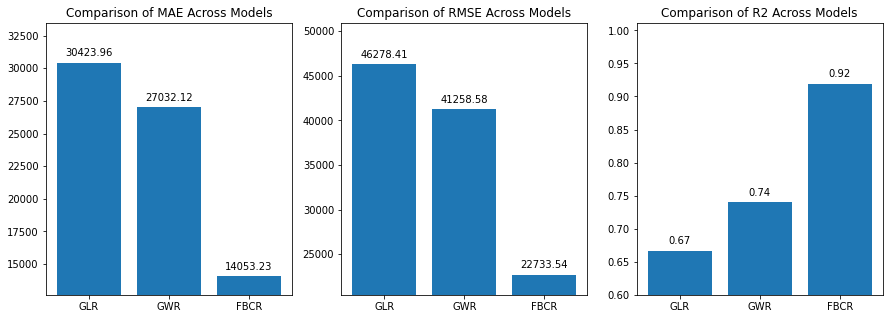

In [30]:
# Define the metrics for each model as a dictionary
metrics = {
    "GLR": [glr_mae, glr_rmse, glr_r2],
    "GWR": [gwr_mae, gwr_rmse, gwr_r2],
    "FBCR": [fbcr_mae, fbcr_rmse, fbcr_r2]
}

# Define the names of the metrics to be plotted
metric_names = ["MAE", "RMSE", "R2"]

# Create a grid of plots
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Loop through each metric and create a bar plot for each model
for i, metric in enumerate(metric_names):
    values = [metrics[model][i] for model in metrics.keys()]
    axs[i].bar(metrics.keys(), values)
    axs[i].set_xlabel("Model")
    axs[i].set_ylabel(metric)
    axs[i].set_title("Comparison of {} Across Models".format(metric))
    axs[i].set_ylim([min(values) * 0.9, max(values) * 1.1])
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    for j, v in enumerate(values):
        if metric == "R2":
            axs[i].text(j, v + 0.01, str(round(v, 2)), ha='center')
        elif metric == "MAE":
            axs[i].text(j, v + 500, str(round(v, 2)), ha='center')
        else:
            axs[i].text(j, v + 750, str(round(v, 2)), ha='center')

    

# Display the plots
plt.show()